# Comparison of Global Context Correlations: All Units vs. 100 Units

This notebook performs a systematic comparison between the correlations calculated for **All Units** and **100 Units** in the Global Context across different  OpenAlex Topics.



In [4]:
#Montar mi google drive para poder usar los archivos
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [5]:

%cd "/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 100/"
!ls

/content/gdrive/.shortcut-targets-by-id/0B5aSrRJgnViLfm9LWl9TY21TWm5wSU0zbkgzc2YyeEp3RzJMaEJOR2FWbFkxVEZYTjNQd1E/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 100
 ai.txt
'All_vs_Citable Documents.html'
 AMEASURE.txt
 figuras
 FMEASURE.txt
 GAggregation.txt
 GMEASURE.txt
 ManuscriptActivityIndexFmeasure_ESI_GlobalContext.ipynb
 manuscriptFiguresAndTables.html
 pearson_correlation_AI_FMeasure.csv
 rsi.txt
 scatterplots
 scatterplots.html
 share.txt
 spearman_correlation_2024.csv
 Spearman_correlation_AI_FMeasure.csv
 Wshare.txt


In [6]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'figure.titlesize': 14,
    'figure.titleweight': 'bold'
})


# Initialize HTML report container
text = """
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Comparison Analysis Report</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; color: #2c3e50; }
        h1, h2, h3 { color: #2c3e50; }
        table { border-collapse: collapse; width: 100%; margin-bottom: 20px; }
        th, td { border: 1px solid #bdc3c7; padding: 8px; text-align: left; }
        th { background-color: #f4f6f7; font-weight: bold; }
        img { max-width: 100%; height: auto; display: block; margin: 20px 0; }
    </style>
</head>
<body>
<h1>Comparison Analysis Report (All vs. 100 Units)</h1>
"""


In [7]:
# Define paths to the CSV files
paths = {
    'all_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/All_Documents/OpenAlex/GlobalContext/pearson_correlation_AI_FMeasure.csv',
    'all_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/All_Documents/OpenAlex/GlobalContext/Spearman_correlation_AI_FMeasure.csv',
    '100_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 100/pearson_correlation_AI_FMeasure.csv',
    '100_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 100/Spearman_correlation_AI_FMeasure.csv'
}

# Load files
dfs = {}
for name, path in paths.items():
    if not os.path.exists(path):
        # Try relative paths as fallback
        if '2026' in path:
            rel_path = f'Global Context/{os.path.basename(path)}'
        else:
            rel_path = f'../../ManuscriptExperiments/Global Context/{os.path.basename(path)}'
        if os.path.exists(rel_path):
            path = rel_path

    dfs[name] = pd.read_csv(path, index_col=0)
    print(f"Successfully loaded {name} (Shape: {dfs[name].shape})")


Successfully loaded all_pearson (Shape: (26, 11))
Successfully loaded all_spearman (Shape: (26, 11))
Successfully loaded 100_pearson (Shape: (26, 11))
Successfully loaded 100_spearman (Shape: (26, 11))


In [8]:
def get_comparison_table(col_name):
    """
    Creates a side-by-side comparison table for a specific correlation column.
    """
    # Base index of OpenAlex Fields from the Pearson All dataset
    index_ref = dfs['all_pearson'].index

    df_comp = pd.DataFrame(index=index_ref)

    # Pearson
    df_comp['Pearson (All)'] = dfs['all_pearson'][col_name]
    df_comp['Pearson (100)'] = dfs['100_pearson'][col_name]
    df_comp['Pearson Diff (100 - All)'] = df_comp['Pearson (100)'] - df_comp['Pearson (All)']

    # Spearman (aligning indices)
    df_comp['Spearman (All)'] = df_comp.index.map(dfs['all_spearman'][col_name])
    df_comp['Spearman (100)'] = df_comp.index.map(dfs['100_spearman'][col_name])
    df_comp['Spearman Diff (100 - All)'] = df_comp['Spearman (100)'] - df_comp['Spearman (All)']

    # Sort OpenAlex Fields alphabetically
    df_comp = df_comp.sort_index()
    return df_comp

def display_styled_table(df, title):
    """
    Applies advanced pandas styler to color-code difference columns and display.
    """
    styled = df.style.format("{:.4f}")\
        .background_gradient(cmap="coolwarm", subset=["Pearson Diff (100 - All)", "Spearman Diff (100 - All)"], vmin=-0.2, vmax=0.2)\
        .set_caption(f"<b style='font-size: 14px;'>{title}</b>")\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f4f6f7'), ('color', '#2c3e50'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'right')]},
            {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
        ])
    display(styled)
    global text
    text = text + f"<h2>{title}</h2>" + styled.to_html() + "<br><br>"

def plot_comparison(df, user_name):
    """
    Generates side-by-side horizontal bar plots to visualize the differences in correlations.
    """
    # Prepare Pearson data for Seaborn
    df_pearson = pd.DataFrame({
        'OpenAlex Field': df.index,
        'All Units': df['Pearson (All)'].values,
        '100 Units': df['Pearson (100)'].values
    }).melt(id_vars='OpenAlex Field', var_name='Dataset', value_name='Pearson Correlation')

    # Prepare Spearman data for Seaborn
    df_spearman = pd.DataFrame({
        'OpenAlex Field': df.index,
        'All Units': df['Spearman (All)'].values,
        '100 Units': df['Spearman (100)'].values
    }).melt(id_vars='OpenAlex Field', var_name='Dataset', value_name='Spearman Correlation')

    fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=True)

    # Harmonious colors: Cool Blue for All, Warm Coral for 100
    colors = {'All Units': '#2b7bba', '100 Units': '#e76f51'}

    # Pearson Subplot
    sns.barplot(
        data=df_pearson,
        y='OpenAlex Field',
        x='Pearson Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[0]
    )
    axes[0].set_title("Pearson Correlation Coefficient", fontsize=13, pad=10)
    axes[0].set_xlabel("Correlation Value")
    axes[0].set_ylabel("OpenAlex Field")
    axes[0].set_xlim(-1.05, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[0].legend().set_visible(False)

    # Spearman Subplot
    sns.barplot(
        data=df_spearman,
        y='OpenAlex Field',
        x='Spearman Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[1]
    )
    axes[1].set_title("Spearman Correlation Coefficient", fontsize=13, pad=10)
    axes[1].set_xlabel("Correlation Value")
    axes[1].set_ylabel("")
    axes[1].set_xlim(-1.05, 1.05)
    axes[1].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[1].legend().set_visible(False)

    # Add single common legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=11)

    plt.suptitle(f"Correlation Comparison: {user_name} (All vs. 100)", fontsize=15, y=1.03)
    plt.tight_layout()
    import os
    os.makedirs('figuras', exist_ok=True)
    fig_name_clean = user_name.replace(' ', '_').replace('/', '_').replace(':', '_').replace('(', '').replace(')', '')
    fig_filename = f"figuras/comparison_{fig_name_clean}.png"
    plt.savefig(fig_filename, bbox_inches='tight')
    global text
    text = text + f"<img src='{fig_filename}' alt='{user_name} Comparison'><br><br>\n"
    plt.show()


## 1. AI vs DShareC Correlation Comparison

This section compares the Pearson and Spearman correlations of **Activity Index (AI)** versus **DShareC**.
This indicator measures how the proportion of publications (AI) relates to the document share in the citation distribution.


,Pearson (All),Pearson (100),Pearson Diff (100 - All),Spearman (All),Spearman (100),Spearman Diff (100 - All)
Agricultural and Biological Sciences,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Arts and Humanities,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
"Biochemistry, Genetics and Molecular Biology",1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
"Business, Management and Accounting",1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Chemical Engineering,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
Chemistry,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
Computer Science,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Decision Sciences,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Dentistry,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Earth and Planetary Sciences,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000


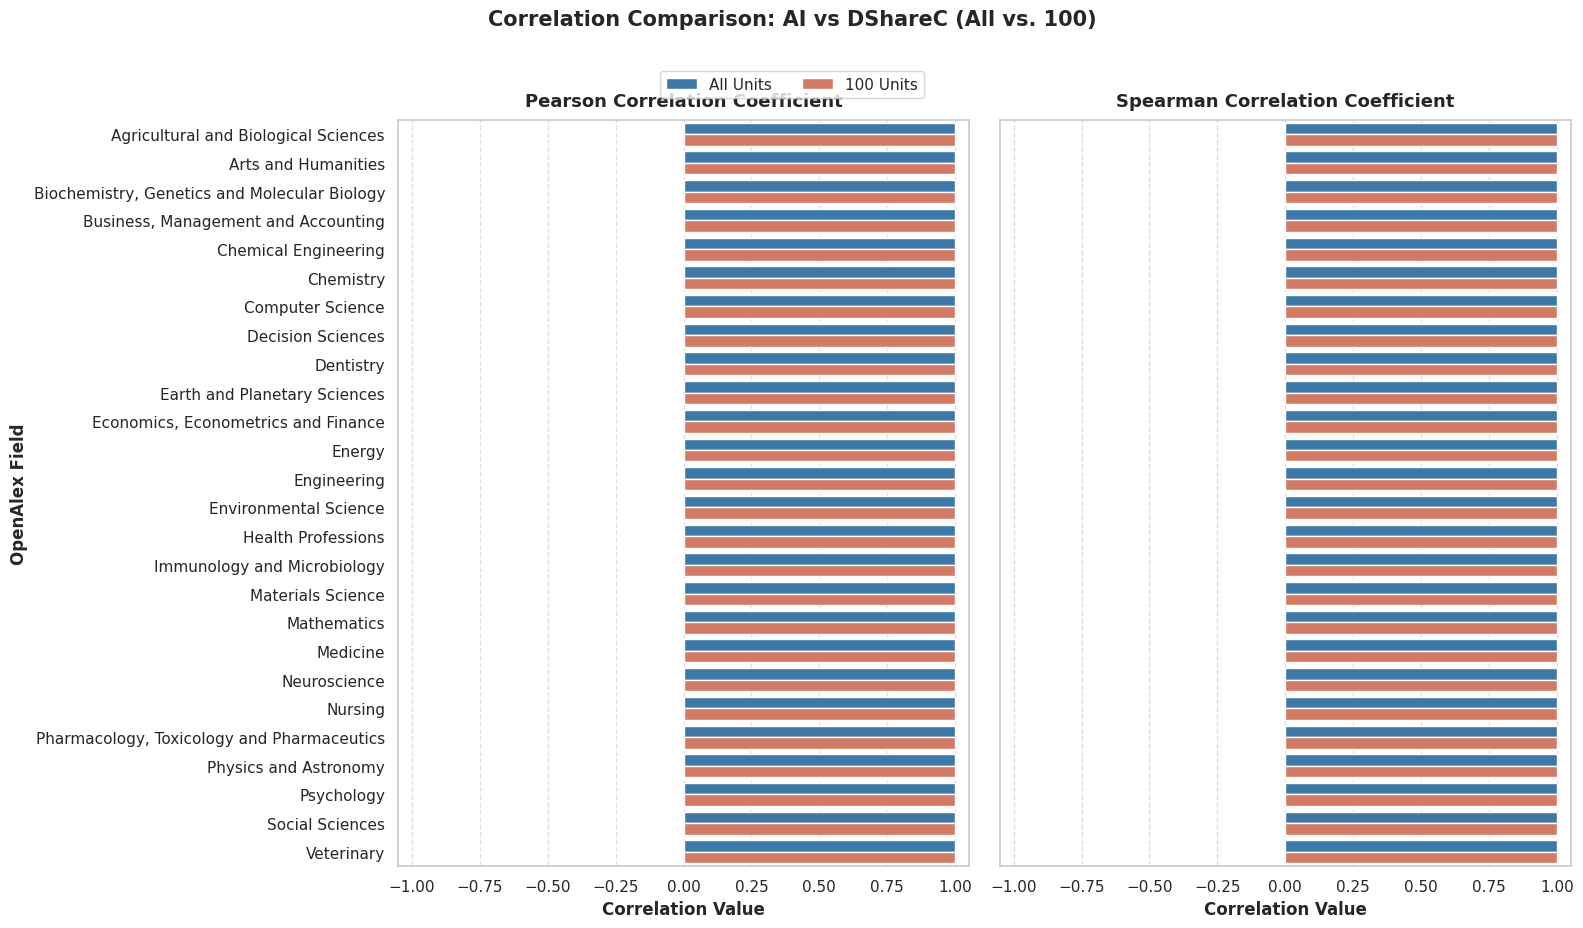

In [9]:
df_ai_dsharec = get_comparison_table('AI vs DShareC')
display_styled_table(df_ai_dsharec, 'Table 1: AI vs DShareC (All vs. 100)')
plot_comparison(df_ai_dsharec, 'AI vs DShareC')


## 2. AI vs CShareD Correlation Comparison

This section compares the correlations of **Activity Index (AI)** versus **CShareD**.


,Pearson (All),Pearson (100),Pearson Diff (100 - All),Spearman (All),Spearman (100),Spearman Diff (100 - All)
Engineering,0.2360,0.4033,0.1674,0.7155,0.3783,-0.3372
Physics and Astronomy,0.1459,0.1955,0.0496,0.6494,0.5724,-0.0770
Materials Science,0.1957,0.3656,0.1698,0.5941,0.5279,-0.0663
Neuroscience,0.2805,0.3195,0.0391,0.5023,0.6200,0.1176
Computer Science,0.1462,0.3445,0.1982,0.4850,0.3969,-0.0881
Chemistry,0.0853,0.3493,0.2641,0.4838,0.5403,0.0565
"Biochemistry, Genetics and Molecular Biology",0.2278,0.3313,0.1034,0.4184,0.5138,0.0953
Chemical Engineering,0.1534,0.4290,0.2756,0.3892,0.5251,0.1359
Energy,0.1015,0.3528,0.2513,0.2997,0.3475,0.0478
Mathematics,-0.0049,0.0648,0.0698,0.2728,0.4305,0.1577


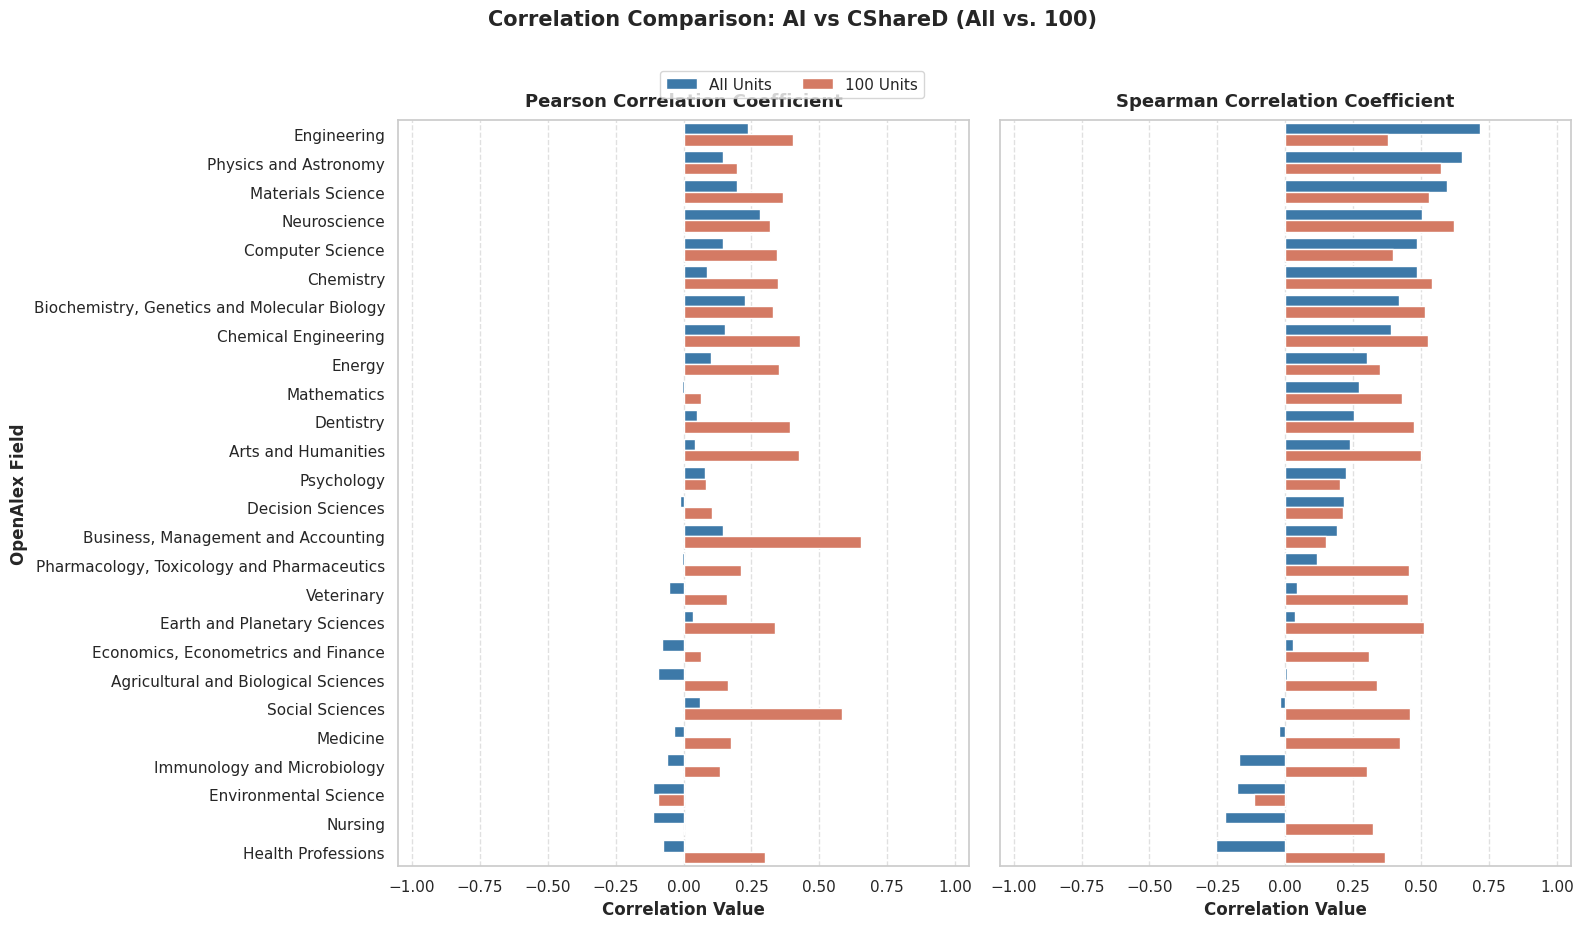

In [10]:
df_ai_cshared = get_comparison_table('AI vs CShareD')
display_styled_table(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'Table 2: AI vs CShareD (All vs. 100)')
plot_comparison(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'AI vs CShareD')


In [11]:
df_ai_cshared.corr(method='spearman')

,Pearson (All),Pearson (100),Pearson Diff (100 - All),Spearman (All),Spearman (100),Spearman Diff (100 - All)
Pearson (All),1.000000,0.680684,-0.020855,0.874188,0.571282,-0.650598
Pearson (100),0.680684,1.000000,0.688205,0.451624,0.459145,-0.231453
Pearson Diff (100 - All),-0.020855,0.688205,1.000000,-0.211624,0.139829,0.364103
Spearman (All),0.874188,0.451624,-0.211624,1.000000,0.576752,-0.784615
Spearman (100),0.571282,0.459145,0.139829,0.576752,1.000000,-0.032479
Spearman Diff (100 - All),-0.650598,-0.231453,0.364103,-0.784615,-0.032479,1.000000


## 3. F-Measure vs DShareC (ShareC) Correlation Comparison

This section compares the correlations of **F-Measure** versus **DShareC**.


,Pearson (All),Pearson (100),Pearson Diff (100 - All),Spearman (All),Spearman (100),Spearman Diff (100 - All)
Engineering,0.2737,0.4328,0.1590,0.7193,0.4036,-0.3157
Physics and Astronomy,0.2556,0.6148,0.3591,0.6693,0.6879,0.0186
Materials Science,0.3153,0.6358,0.3205,0.6154,0.6605,0.0451
Neuroscience,0.4715,0.7060,0.2344,0.5377,0.7590,0.2214
Chemistry,0.1508,0.7936,0.6428,0.5125,0.7324,0.2199
Computer Science,0.1936,0.4323,0.2387,0.4930,0.4135,-0.0795
Chemical Engineering,0.2660,0.9304,0.6643,0.4840,0.9065,0.4224
"Biochemistry, Genetics and Molecular Biology",0.3024,0.4530,0.1506,0.4309,0.5794,0.1485
Energy,0.1927,0.8128,0.6200,0.3565,0.7449,0.3884
Dentistry,0.2256,0.9399,0.7144,0.3556,0.8874,0.5319


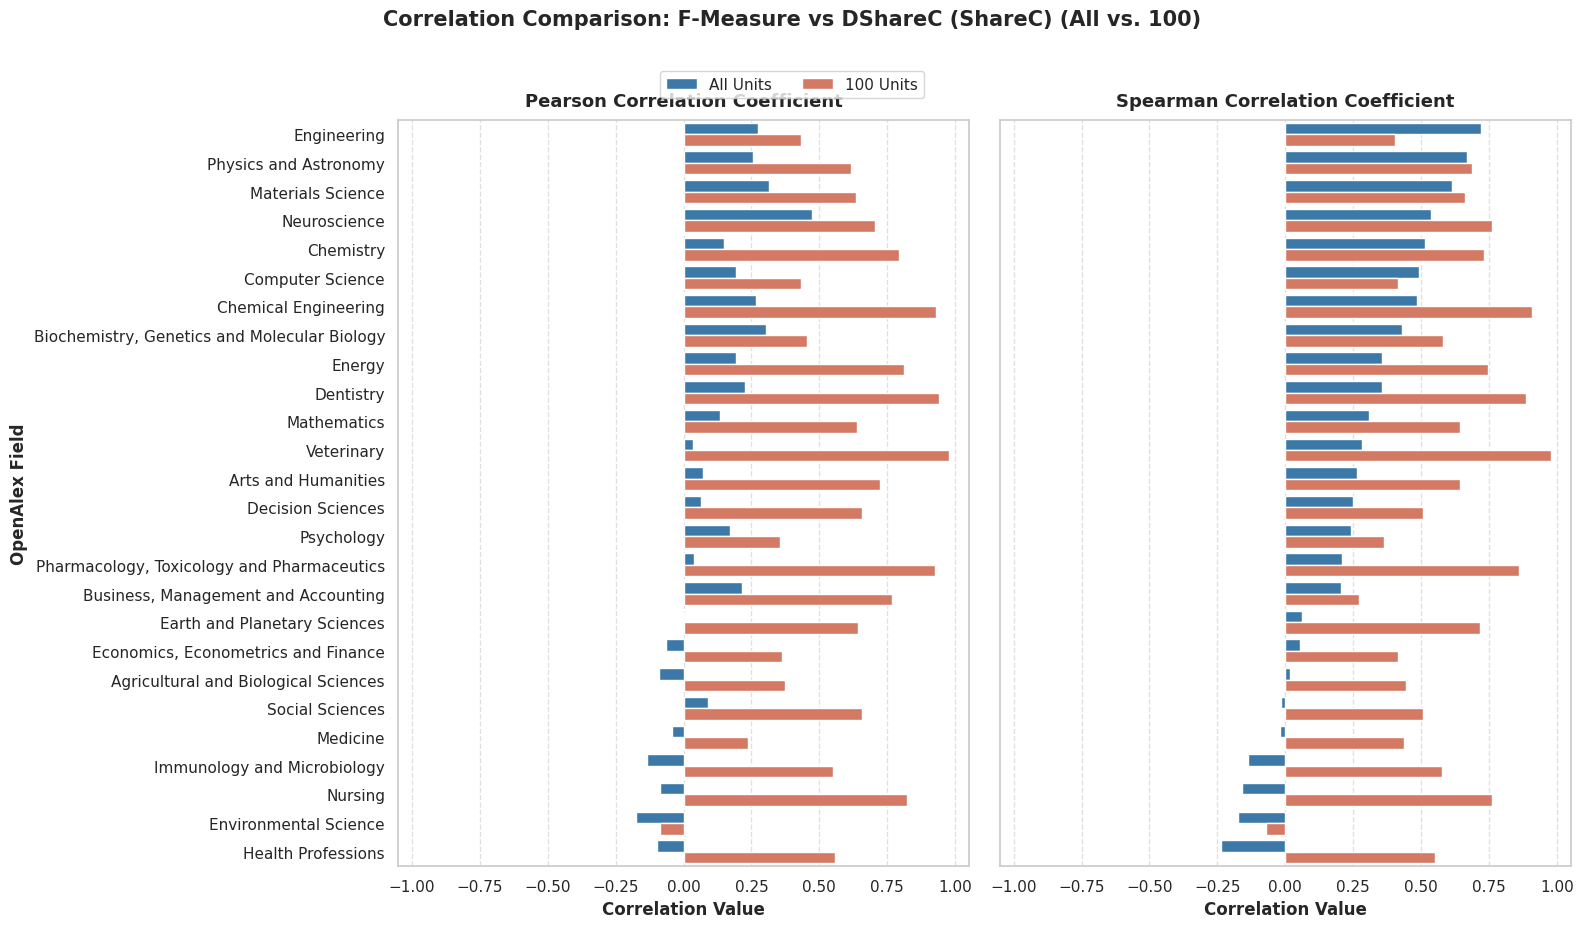

In [12]:
df_f_dsharec = get_comparison_table('F-Measure vs DShareC')
display_styled_table(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'Table 3: F-Measure vs DShareC (All vs. 100)')
plot_comparison(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'F-Measure vs DShareC (ShareC)')



In [13]:
df_f_dsharec.corr(method='spearman')

,Pearson (All),Pearson (100),Pearson Diff (100 - All),Spearman (All),Spearman (100),Spearman Diff (100 - All)
Pearson (All),1.000000,0.240342,-0.330598,0.877607,0.208276,-0.606838
Pearson (100),0.240342,1.000000,0.766154,0.234188,0.811902,0.386667
Pearson Diff (100 - All),-0.330598,0.766154,1.000000,-0.253333,0.668947,0.777094
Spearman (All),0.877607,0.234188,-0.253333,1.000000,0.304720,-0.623932
Spearman (100),0.208276,0.811902,0.668947,0.304720,1.000000,0.478796
Spearman Diff (100 - All),-0.606838,0.386667,0.777094,-0.623932,0.478796,1.000000


## 4. F-Measure vs CShareD Correlation Comparison

This section compares the correlations of **F-Measure** versus **CShareD**.


,Pearson (All),Pearson (100),Pearson Diff (100 - All),Spearman (All),Spearman (100),Spearman Diff (100 - All)
Medicine,0.9864,0.9852,-0.0012,1.0000,0.9990,-0.0009
Environmental Science,0.9123,0.9134,0.0011,0.9999,0.9967,-0.0032
Social Sciences,0.9780,0.9860,0.0080,0.9999,0.9964,-0.0035
Engineering,0.9864,0.9901,0.0037,0.9999,0.9978,-0.0021
Computer Science,0.9567,0.9500,-0.0067,0.9999,0.9988,-0.0010
Agricultural and Biological Sciences,0.9034,0.8982,-0.0052,0.9998,0.9885,-0.0113
"Biochemistry, Genetics and Molecular Biology",0.9306,0.9231,-0.0075,0.9997,0.9868,-0.0128
Psychology,0.8596,0.8278,-0.0318,0.9996,0.9754,-0.0242
Health Professions,0.8588,0.8549,-0.0040,0.9996,0.9552,-0.0443
"Business, Management and Accounting",0.9271,0.9633,0.0362,0.9995,0.9864,-0.0131


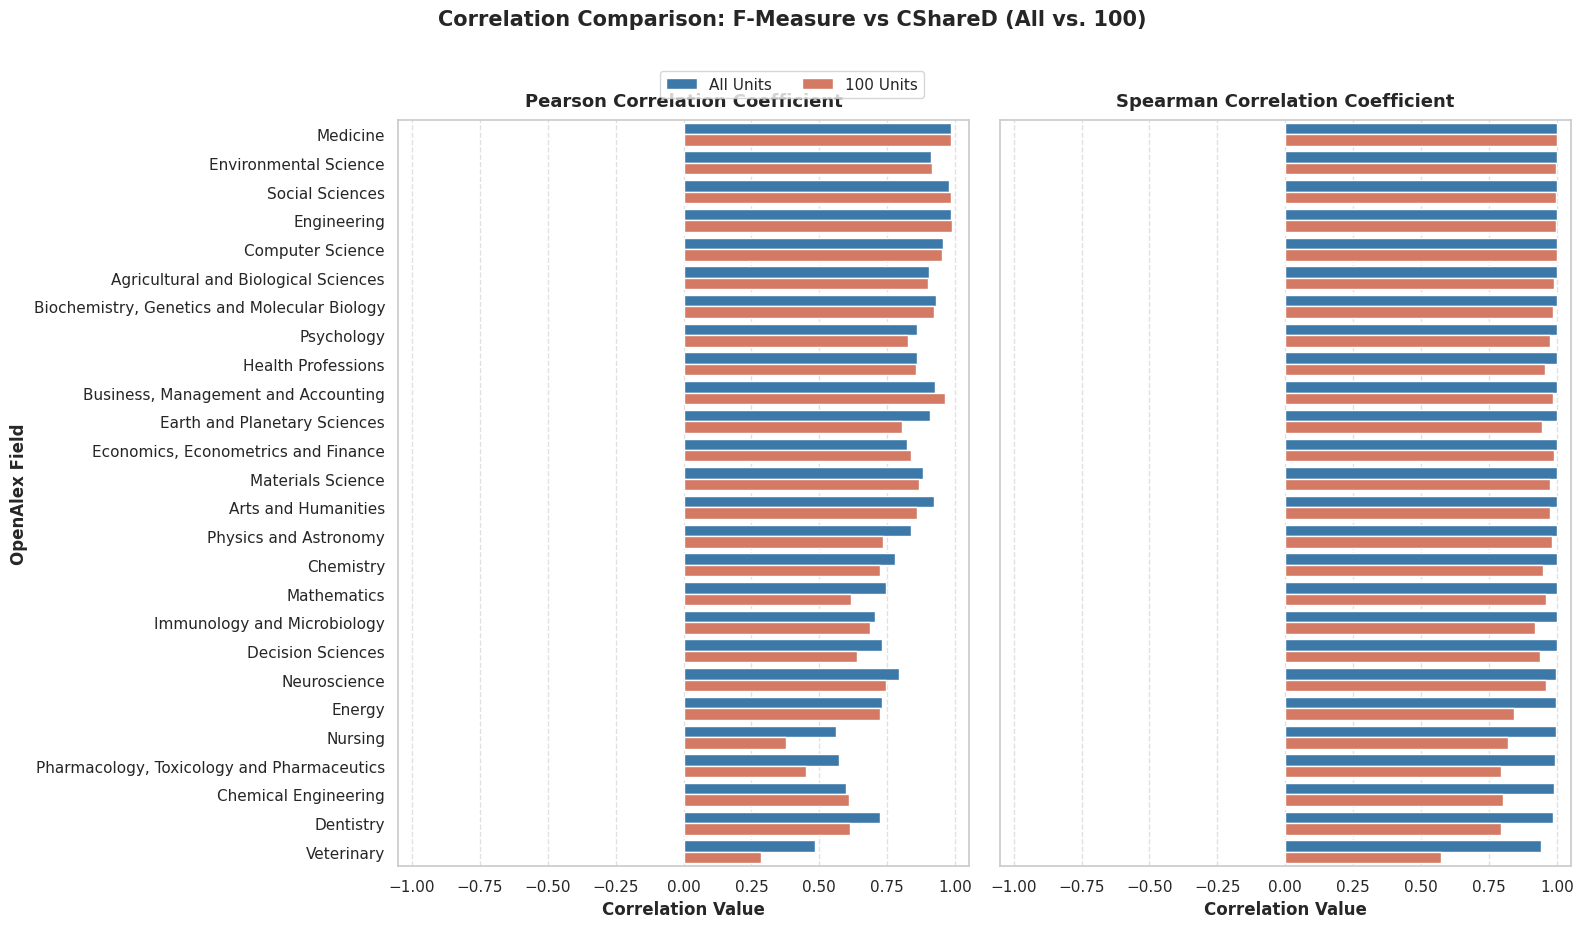

In [14]:
df_f_cshared = get_comparison_table('F-Measure vs CShareD')
display_styled_table(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'Table 4: F-Measure vs CShareD (All vs. 100)')
plot_comparison(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'F-Measure vs CShareD')


## 5. Summary Statistics and Overall Analysis (Absolute Discrepancies)

To synthesize the comparison, let's look at the summary statistics of the **absolute differences** across all 22 OpenAlex Fields for each of the four indicator pairs.

Using absolute values is essential because it measures the magnitude of the discrepancy (change) regardless of whether the correlation went up or down. For example, a large negative change like -0.76708 represents a major discrepancy of 0.76708 in absolute terms. Computing statistics on signed differences can cause positive and negative changes to cancel each other out, hiding the true extent of the changes.


In [15]:
summary_data = []
pairs_mapping = {
    'AI vs DShareC': 'AI vs DShareC',
    'AI vs CShareD': 'AI vs CShareD',
    'F-Measure vs DShareC': 'F-Measure vs DShareC',
    'F-Measure vs CShareD': 'F-Measure vs CShareD'
}

for user_name, csv_name in pairs_mapping.items():
    df_p = get_comparison_table(csv_name)
    pearson_abs = df_p['Pearson Diff (100 - All)'].abs()
    spearman_abs = df_p['Spearman Diff (100 - All)'].abs()
    summary_data.append({
        'Indicator Pair': user_name,
        'Mean Abs Pearson Diff': pearson_abs.mean(),
        'Median Abs Pearson Diff': pearson_abs.median(),
        'Max Abs Pearson Diff': pearson_abs.max(),
        'Min Abs Pearson Diff': pearson_abs.min(),
        'Mean Abs Spearman Diff': spearman_abs.mean(),
        'Median Abs Spearman Diff': spearman_abs.median(),
        'Max Abs Spearman Diff': spearman_abs.max(),
        'Min Abs Spearman Diff': spearman_abs.min()
    })

df_summary = pd.DataFrame(summary_data).set_index('Indicator Pair')

styled_summary = df_summary.style.format("{:.5f}")\
    .background_gradient(cmap="Reds", vmin=0.0, vmax=0.3)\
    .set_caption("<b style='font-size: 14px;'>Overall Comparison Summary: Absolute Discrepancies (|100 - All|)</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
        {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
    ])
display(styled_summary)
global text
text = text + "<h2>Overall Comparison Summary</h2>" + styled_summary.to_html() + "<br><br>"


,Mean Abs Pearson Diff,Median Abs Pearson Diff,Max Abs Pearson Diff,Min Abs Pearson Diff,Mean Abs Spearman Diff,Median Abs Spearman Diff,Max Abs Spearman Diff,Min Abs Spearman Diff
Indicator Pair,,,,,,,,
AI vs DShareC,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
AI vs CShareD,0.21209,0.20410,0.52327,0.00573,0.23777,0.18937,0.61972,0.00188
F-Measure vs DShareC,0.50538,0.55901,0.94507,0.08766,0.37840,0.36795,0.92051,0.01856
F-Measure vs CShareD,0.05313,0.02481,0.19914,0.00108,0.06884,0.03239,0.36572,0.00094


In [16]:
global text
text = text + "</body></html>"
with open("All_vs_100 Units.html", "w", encoding="utf-8") as f:
    f.write(text)
print("Saved report to All_vs_100 Units.html")


Saved report to All_vs_100 Units.html
